# MPW2 - Computational graphs

**Student 1: Rauch, Kaj**   
**Student 2: Martinez Rio, Helena**

In [1]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [2]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [3]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [4]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [5]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend,
# also optional.
def plot_data_prediction(
    x_points,
    y_points,
    x_curve=None,
    y_curve=None,
    x_title="x",
    y_title="y",
    theta_0=None,
    theta_1=None,
    theta_2=None,
):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)  # ex "Living area (m^2)"
    plt.ylabel(y_title)  # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = rf"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += rf", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

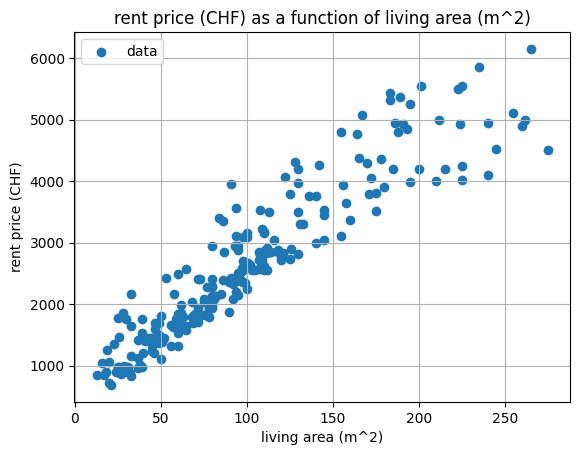

In [6]:
plot_data_prediction(
    living_area, rent_price, x_title="living area (m^2)", y_title="rent price (CHF)"
)

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


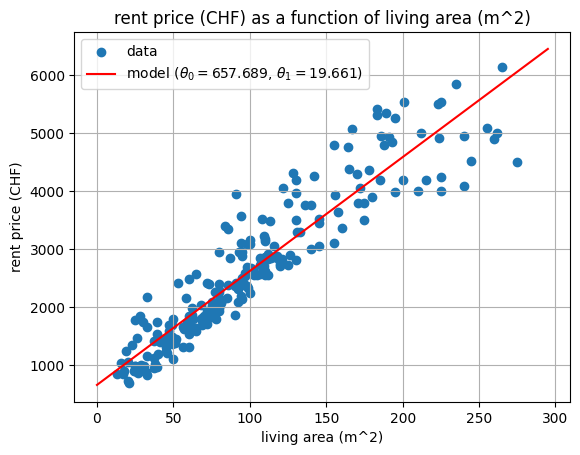

In [7]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price
theta = inv(X.T @ X) @ X.T @ y

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title="living area (m^2)",
    y_title="rent price (CHF)",
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [8]:
def mse_loss(y_hat, y):
    residual = y_hat - y
    return 0.5 * np.mean(residual * residual)


y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [9]:
def rmse_loss(y_hat, y):
    residual = y_hat - y
    return np.sqrt(np.mean(residual * residual))


def mae_loss(y_hat, y):
    residual = y_hat - y
    return np.mean(np.abs(residual))


def mape_loss(y_hat, y):
    residual = y_hat - y
    eps = 1e-12
    return np.mean(np.abs(residual) / (np.abs(y) + eps))


rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


The linear model follows the general trend of the data reasonably well, but there is still a lot of spread around the fitted line.
The RMSE (~458 CHF) and MAE (~347 CHF) both show that predictions can be off by several hundred francs on average, which makes sense given how scattered the data is.
MAPE gives a relative view (~14.6%), useful when you want to know the error as a fraction of the actual price.

Potential issue with MAPE: it divides by $y$, so if any rent value is zero or very small, the percentage blows up.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [10]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
x = ValueNode()
theta_0 = ValueNode()
theta_1 = ValueNode()
y = ValueNode()
q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
mse = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [11]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [12]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [13]:
# this function plots the evolution of the loss and the parameters during training, as well
# as the data points and the model curve at the end of training. The last value of the
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle("Training log")
    ax1.plot(t0_evolution)
    ax1.set_title("theta 0")
    ax2.plot(t1_evolution)
    ax2.set_title("theta 1")
    ax3.plot(loss_evolution)
    ax3.set_title("loss")
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = (
        t0_evolution[-1] + t1_evolution[-1] * x_curve
    )  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color="red")
    ax4.set_title("points and model output")
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 0.9983653333614485
slope (theta_1)    : 24.69578830952895
The total value of the loss is 163640.73522310136


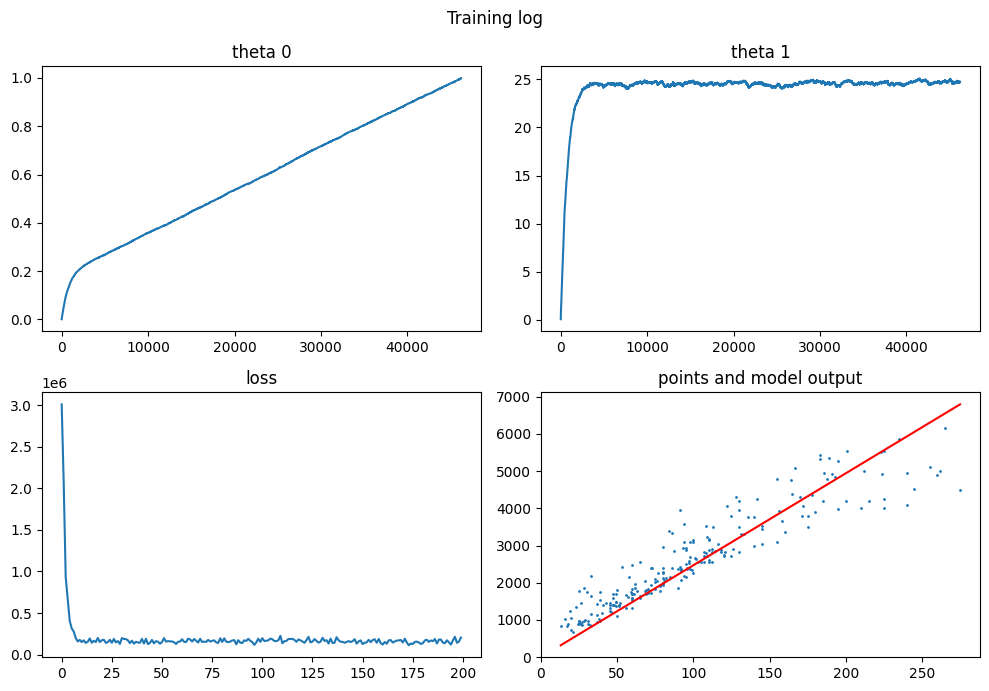

In [14]:
alpha = 0.0000001  # learning rate
epochs = 200  # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0  # initial value of theta_0
t1 = 0.0  # initial value of theta_1

loss_evolution_sgd = []  # to log the evolution of the loss
t0_evolution_sgd = []  # to log the evolution of theta_0
t1_evolution_sgd = []  # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v  # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution_sgd.append(t0)
        t1_evolution_sgd.append(t1)
    loss_evolution_sgd.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution_sgd, t0_evolution_sgd, t1_evolution_sgd, living_area, rent_price)

**Your observations**

- Evolution of the loss: drops fast at first, then slows down and stays noisy because each update uses only one sample.
- Evolution of theta_1: reaches a value close to the normal-equation result fairly quickly and does not move much after that.
- Evolution of theta_0: moves in the right direction but very slowly — after 200 epochs it is still far from ~658.

### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.46245094376390533
slope (theta_1)    : 24.492612082906493
The total value of the loss is 163533.98304820905


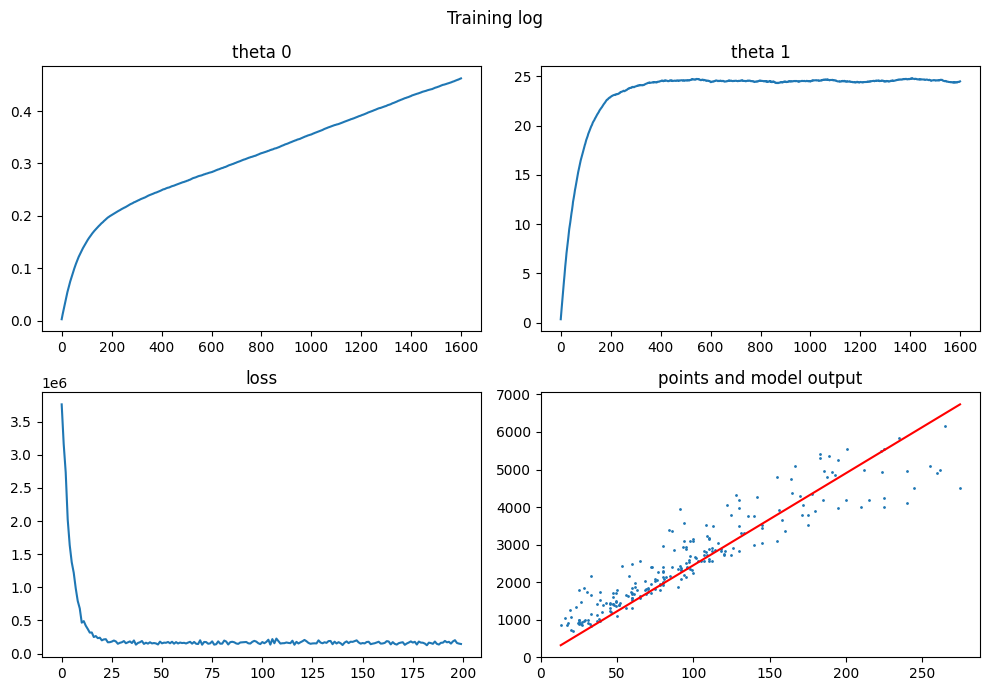

In [15]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD
# as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution_batch = []
t0_evolution_batch = []
t1_evolution_batch = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    for step in range(n_steps):
        batch_indices = random.sample(range(0, N), k=min(batch_size, N))
        grad_t0_sum = 0.0
        grad_t1_sum = 0.0
        batch_loss = 0.0

        # compute the gradients and update theta_0 and theta_1 with the average
        # of the gradients over the batch
        for n in batch_indices:
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()
            grad_t0_sum += theta_0.grad_v
            grad_t1_sum += theta_1.grad_v
            batch_loss += j.v

        grad_t0_avg = grad_t0_sum / len(batch_indices)
        grad_t1_avg = grad_t1_sum / len(batch_indices)
        t0 = t0 - alpha * grad_t0_avg
        t1 = t1 - alpha * grad_t1_avg

        epoch_loss += batch_loss / len(batch_indices)
        t0_evolution_batch.append(t0)
        t1_evolution_batch.append(t1)

    loss_evolution_batch.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution_batch, t0_evolution_batch, t1_evolution_batch, living_area, rent_price)

**Your observations**

- Evolution of theta_0 and theta_1: both curves are smoother than in plain SGD because gradients are averaged over the batch before each update.
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0? Yes, theta_1 still converges faster and theta_0 still lags behind, the problem is just less noisy.
- Can we use larger learning rates than in the plain stochastic version? Yes, because averaging over a batch reduces the variance of the gradient estimate, so bigger steps are less likely to cause divergence.

## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 651.5017960636001
slope (theta_1)    : 19.72760963525506
The total value of the loss is 104923.16731499242


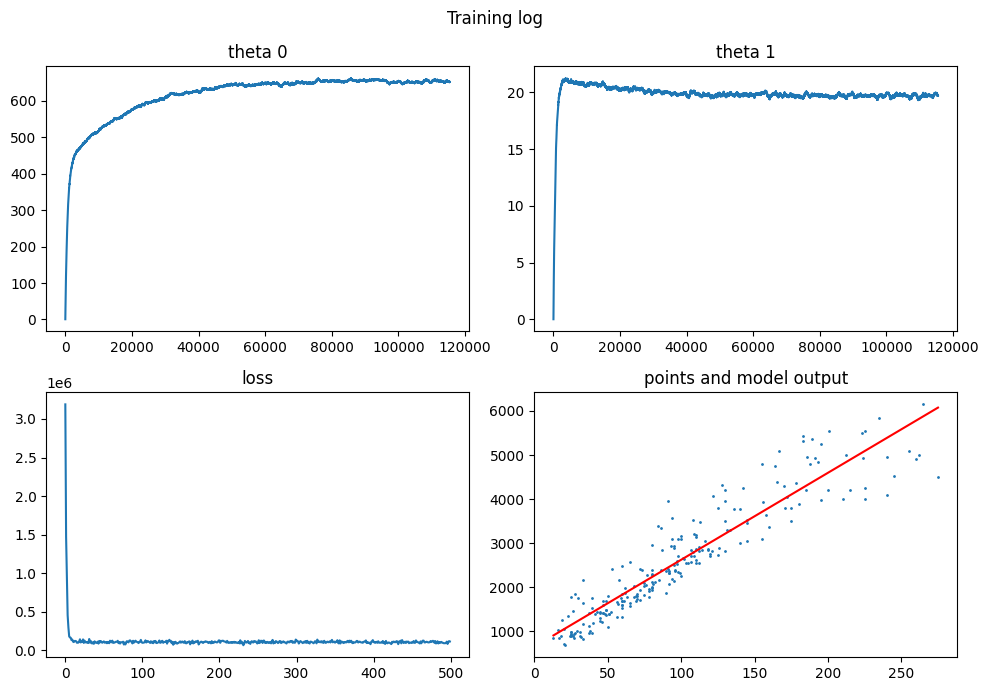

In [16]:
alpha_t0 = 0.00025  # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500  # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution_lrsep = []
t0_evolution_lrsep = []
t1_evolution_lrsep = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v
        epoch_loss += j.v
        t0_evolution_lrsep.append(t0)
        t1_evolution_lrsep.append(t1)
    loss_evolution_lrsep.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution_lrsep, t0_evolution_lrsep, t1_evolution_lrsep, living_area, rent_price)

**Your observations**.

- Giving theta_0 a much larger learning rate lets it catch up to its correct value within a reasonable number of epochs.
- theta_1 converges quickly even with a small rate, so we do not need to change it much.
- This shows that the slow convergence of theta_0 was mainly a learning rate problem, not something fundamental about the data.

### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which reaches a stable value quickly, with gradients that change direction more often. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 661.9708040491035
slope (theta_1)    : 19.42970531847308
The total value of the loss is 105183.40018280137


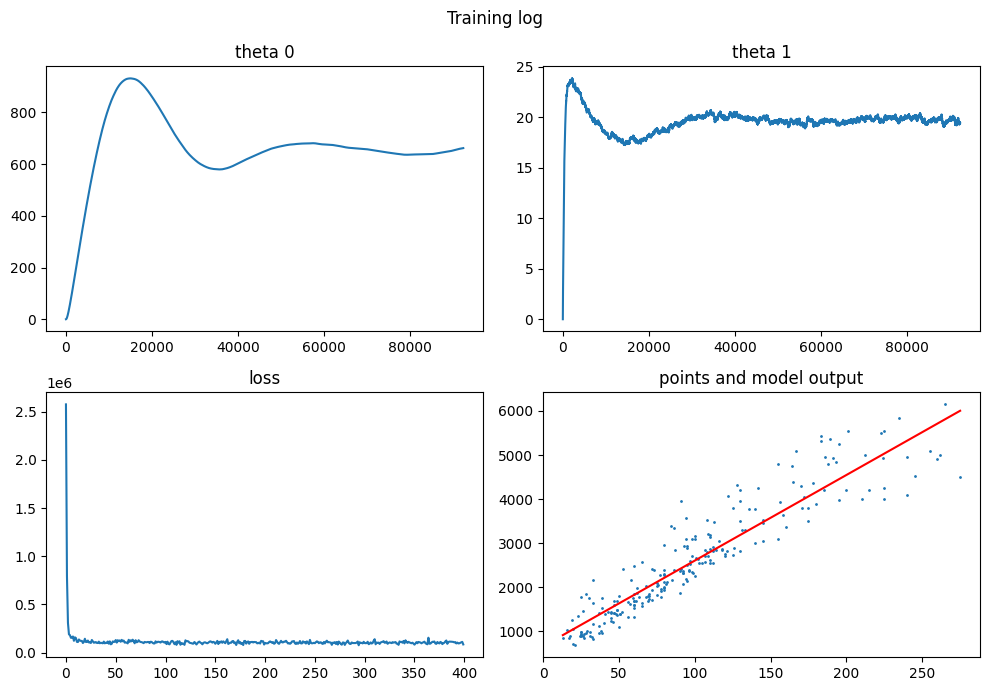

In [17]:
alpha = 0.0000001  # learning rate
beta_momentum_t0 = 0.9999  # momentum factor for theta_0
beta_momentum_t1 = 0.5000  # momentum factor for theta_1
epochs = 400  # number of epochs (an epoch is a loop over the whole training set)

N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution_momentum = []
t0_evolution_momentum = []
t1_evolution_momentum = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v

        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        epoch_loss += j.v
        t0_evolution_momentum.append(t0)
        t1_evolution_momentum.append(t1)
    loss_evolution_momentum.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution_momentum, t0_evolution_momentum, t1_evolution_momentum, living_area, rent_price)

**Your observations**

- theta_0 converges to ~662 in 400 epochs, whereas plain SGD barely moved it away from 0 after 200 epochs — the high beta (0.9999) builds up speed in a consistent direction and keeps going.
- theta_1 was already converging fast without momentum, so a lower beta (0.5) was enough; a high beta there would have caused it to overshoot its target.
- The final MSE (~105,183) is close to the normal-equation optimum (~104,915), which confirms that momentum fixed the main bottleneck without hurting the result.

## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- **Implement an early stopping strategy in your training loop.**
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- **Normalize the input data with a zero norm approach and compare to your experiments without normalization.**


## Optional 1: Early stopping

Early stopping monitors a validation loss during training and stops the training when the loss stops improving for a fixed number of iterations (patience). 

**Strategy**:
1. Split dataset into a training set and a validation set. (80% training, 20% validation)
1. During training, after each epoch, compute the loss on the validation set.
1. If the validation loss does not improve for a number of consecutive epochs equal to the patience, stop the training.
1. Restore the best parameters to the values that achieved the best validation loss.

Training set size: 185
Validation set size: 46
Early stopping at epoch 64
Best intercept (theta_0): 0.2245498535432529
Best slope (theta_1): 24.03242387842647
Final MSE (full data): 165183.07
Final MSE (validation): 141440.21


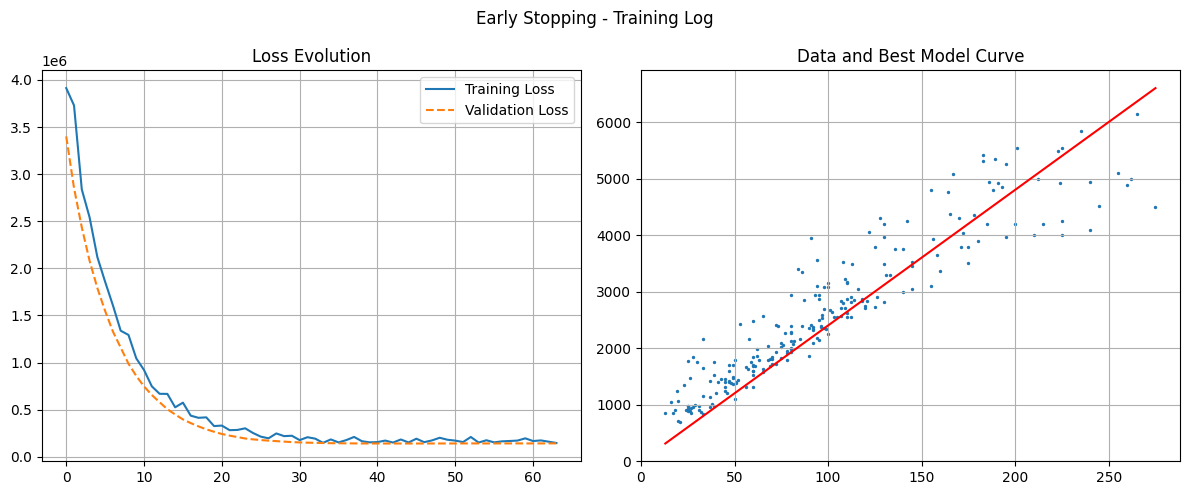

In [18]:
# Train / validation split
random.seed(42)
indices = list(range(len(living_area)))
random.shuffle(indices)
val_size = int(0.2 * len(living_area))
val_idx = indices[:val_size]
train_idx = indices[val_size:]

x_train, y_train = living_area[train_idx], rent_price[train_idx]
x_val, y_val = living_area[val_idx], rent_price[val_idx]

print("Training set size:", len(x_train))
print("Validation set size:", len(x_val))

# Hyperparameters for early stopping
alpha = 0.000001
batch_size = 32
max_epochs = 2000
patience = 20

t0, t1 = 0.0, 0.0
best_t0, best_t1 = t0, t1
best_val_loss = float("inf")
epochs_without_improvement = 0

loss_evolution_es = []
val_loss_evolution_es = []
t0_evolution_es = []
t1_evolution_es = []

N_train = len(x_train)

for epoch in range(max_epochs):
    n_steps = N_train // batch_size + 1
    epoch_loss = 0.0

    for step in range(n_steps):
        batch_indices = random.sample(range(0, N_train), k=min(batch_size, N_train))
        grad_t0_sum = 0.0
        grad_t1_sum = 0.0
        batch_loss = 0.0

        for n in batch_indices:
            cg.reset_values()
            cg.forward([x_train[n], t0, t1, y_train[n]])
            cg.backward()
            grad_t0_sum += theta_0.grad_v
            grad_t1_sum += theta_1.grad_v
            batch_loss += j.v

        grad_t0_avg = grad_t0_sum / len(batch_indices)
        grad_t1_avg = grad_t1_sum / len(batch_indices)
        t0 = t0 - alpha * grad_t0_avg
        t1 = t1 - alpha * grad_t1_avg

        epoch_loss += batch_loss / len(batch_indices)

        t0_evolution_es.append(t0)
        t1_evolution_es.append(t1)

    train_loss = epoch_loss / n_steps
    loss_evolution_es.append(train_loss)

    # Compute validation loss
    y_hat_val = t0 + t1 * x_val
    val_loss = mse_loss(y_hat_val, y_val)
    val_loss_evolution_es.append(val_loss)

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_t0, best_t1 = t0, t1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

# Restore best parameters
t0, t1 = best_t0, best_t1
print("Best intercept (theta_0):", t0)
print("Best slope (theta_1):", t1)
y_hat = t0 + t1 * living_area
print(f"Final MSE (full data): {mse_loss(y_hat, rent_price):.2f}")
print(f"Final MSE (validation): {best_val_loss:.2f}")


# Plot training and validation loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Early Stopping - Training Log")
ax1.plot(loss_evolution_es, label="Training Loss")
ax1.plot(val_loss_evolution_es, label="Validation Loss", linestyle="--")
ax1.set_title("Loss Evolution")
ax1.legend()
ax1.grid(True)
ax2.scatter(living_area, rent_price, s=2)
x_curve = np.array(np.linspace(np.min(living_area), np.max(living_area), 200))
ax2.plot(x_curve, t0 + t1 * x_curve, color="red")
ax2.set_title("Data and Best Model Curve")
ax2.grid(True)
plt.tight_layout()
plt.show()

## Optional 2: Normalize

Normalize the input data with zero-mean normalization (z-score) and compare the results to the experiments without normalization.


In [ ]:
# Optional 2: zero-mean normalization
x_mean = float(np.mean(living_area))
x_std = float(np.std(living_area))
x_norm = (living_area - x_mean) / x_std

alpha_norm = 0.01
epochs_norm = 400
t0_n = 0.0
t1_n = 0.0
loss_evolution_norm = []

N = len(x_norm)
indices = list(range(N))
random.seed(0)
for epoch in range(epochs_norm):
    random.shuffle(indices)
    epoch_loss = 0.0
    for n in indices:
        cg.reset_values()
        cg.forward([float(x_norm[n]), t0_n, t1_n, float(rent_price[n])])
        cg.backward()
        t0_n -= alpha_norm * theta_0.grad_v
        t1_n -= alpha_norm * theta_1.grad_v
        epoch_loss += j.v
    loss_evolution_norm.append(epoch_loss / N)

theta0_equiv = t0_n - (t1_n * x_mean / x_std)
theta1_equiv = t1_n / x_std
print(f"Normalized model (raw scale): theta_0={theta0_equiv:.2f}, theta_1={theta1_equiv:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(loss_evolution_sgd,      label='Plain SGD (200 ep)')
ax1.plot(loss_evolution_batch,    label='Mini-batch SGD (200 ep)')
ax1.plot(loss_evolution_lrsep,    label='Separate LR (500 ep)')
ax1.plot(loss_evolution_momentum, label='Momentum (400 ep)')
ax1.plot(loss_evolution_norm,     label='Normalized SGD (400 ep)', linewidth=2, linestyle='--', color='green')
ax1.set_title('Loss evolution — all experiments vs normalization')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.legend(fontsize=8)
ax1.grid(True)

x_curve = np.linspace(np.min(living_area), np.max(living_area), 200)
ax2.scatter(living_area, rent_price, s=8, label='data')
ax2.plot(x_curve, t0_evolution_sgd[-1]      + t1_evolution_sgd[-1]      * x_curve, label='Plain SGD',      alpha=0.6)
ax2.plot(x_curve, t0_evolution_batch[-1]    + t1_evolution_batch[-1]    * x_curve, label='Mini-batch',     alpha=0.6)
ax2.plot(x_curve, t0_evolution_lrsep[-1]    + t1_evolution_lrsep[-1]    * x_curve, label='Separate LR',   alpha=0.6)
ax2.plot(x_curve, t0 + t1 * x_curve,                                               label='Momentum',      alpha=0.6)
ax2.plot(x_curve, theta0_equiv + theta1_equiv * x_curve, color='green', linewidth=2, linestyle='--', label='Normalized')
ax2.set_title('Model comparison')
ax2.set_xlabel('living area (m^2)')
ax2.set_ylabel('rent price (CHF)')
ax2.legend(fontsize=8)
ax2.grid(True)

fig.tight_layout()


### Our MSE loss

In [20]:
class MSELossNode(MetaNode):
    """A binary MSE loss node for one sample: j = 0.5 * (y_hat - y)^2."""

    def __init__(self, y_hat: ValueNode, y: ValueNode, out: ValueNode):
        """Create a scalar MSE loss node.

        Args:
            y_hat: Predicted value node.
            y: Ground-truth value node.
            out: Output node receiving the scalar loss.
        """
        super().__init__()
        y_hat.connect_to(self)
        y.connect_to(self)
        self.connect_to(out)
        self._received_count = 0

    def get_parent_values(self) -> tuple[float, float]:
        """Return parent values in fixed order ``(y_hat, y)``."""
        return self.parents[0].v, self.parents[1].v

    def receive_parent_value(self, v: float):
        """Record one input arrival and mark readiness when both arrived."""
        del v  # parent values are read directly from parents during passes
        if self._received_count >= 2:
            raise Exception("This node accepts 2 inputs that are already filled")
        self._received_count += 1
        if self._received_count == 2:
            self.input_ready = True

    def reset_values(self):
        """Reset readiness counters and recursively reset descendants."""
        self._received_count = 0
        self.input_ready = False
        for node in self.children:
            node.reset_values()

    def forward(self):
        """Compute scalar loss and push it to children."""
        if self.input_ready:
            y_hat, y = self.get_parent_values()
            j = 0.5 * (y_hat - y) * (y_hat - y)
            for node in self.children:
                node.receive_parent_value(j)
                node.forward()

    def backward(self, grad_z):
        """Backpropagate gradients to ``y_hat`` and ``y`` inputs."""
        y_hat, y = self.get_parent_values()
        grad_y_hat = (y_hat - y) * grad_z
        grad_y = -(y_hat - y) * grad_z
        self.parents[0].backward(grad_y_hat)
        self.parents[1].backward(grad_y)
